<a href="https://colab.research.google.com/github/VBerkYayla/AnimatedGraphics/blob/main/MC_EC_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np # linear algebra
import pandas as pd # data processing, reading CSV file
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import warnings

# I took this section directly from the code of the person who provided me with the data, so it includes everything

In [37]:
import kagglehub
urvishahir_electric_vehicle_specifications_dataset_2025_path = kagglehub.dataset_download('urvishahir/electric-vehicle-specifications-dataset-2025')

print('Data source import complete.') # We pull the dataset directly from Kaggle, so even if the data is updated, the updated version is automatically reflected in our code.


Using Colab cache for faster access to the 'electric-vehicle-specifications-dataset-2025' dataset.
Data source import complete.


In [38]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'): #We retrieve the file path of the data using the `import os` function.
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/electric-vehicle-specifications-dataset-2025/electric_vehicles_spec_2025.csv.csv


In [39]:
df = pd.read_csv("/kaggle/input/electric-vehicle-specifications-dataset-2025/electric_vehicles_spec_2025.csv.csv") # We are saving the data as df.

In [40]:
df.head() # We call head() to examine the top portion of the data.

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [41]:
print("Dataset size:", df.shape) # 478 EV models and 22 columns we get

Dataset size: (478, 22)


In [42]:
df.info() # We can learn NN count in the data with info and also see the memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    object 
 1   model                      477 non-null    object 
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    object 
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    object 
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    object 

In [43]:
df.describe()

,top_speed_kmh,battery_capacity_kWh,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
count,478.000000,478.000000,276.000000,471.000000,478.000000,478.000000,478.000000,477.000000,452.000000,478.000000,478.000000,478.000000,478.000000
mean,185.487448,74.043724,485.293478,498.012739,162.903766,393.179916,6.882636,125.008386,1052.261062,5.263598,4678.506276,1887.359833,1601.125523
std,34.252773,20.331058,1210.819733,241.461128,34.317532,103.287335,2.730696,58.205012,737.851774,1.003961,369.210573,73.656807,130.754851
min,125.000000,21.300000,72.000000,113.000000,109.000000,135.000000,2.200000,29.000000,0.000000,2.000000,3620.000000,1610.000000,1329.000000
25%,160.000000,60.000000,150.000000,305.000000,143.000000,320.000000,4.800000,80.000000,500.000000,5.000000,4440.000000,1849.000000,1514.000000
50%,180.000000,76.150000,216.000000,430.000000,155.000000,397.500000,6.600000,113.000000,1000.000000,5.000000,4720.000000,1890.000000,1596.000000
75%,201.000000,90.600000,324.000000,679.000000,177.750000,470.000000,8.200000,150.000000,1600.000000,5.000000,4961.000000,1939.000000,1665.000000
max,325.000000,118.000000,7920.000000,1350.000000,370.000000,685.000000,19.100000,281.000000,2500.000000,9.000000,5908.000000,2080.000000,1986.000000


In [44]:
print("Number of feature:", df.shape[1] - 1)  # hedef sütun hariç
print("Number of entries:", df.shape[0])
print("\nNumerical characteristics:")
print(df.select_dtypes(include='number').columns.tolist())
print("\nCategorical characteristics:")
print(df.select_dtypes(include='object').columns.tolist())
print("\nTarget variable (range_km) distribution:")
print(df['range_km'].describe())

Number of feature: 21
Number of entries: 478

Numerical characteristics:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm']

Categorical characteristics:
['brand', 'model', 'battery_type', 'fast_charge_port', 'cargo_volume_l', 'drivetrain', 'segment', 'car_body_type', 'source_url']

Target variable (range_km) distribution:
count    478.000000
mean     393.179916
std      103.287335
min      135.000000
25%      320.000000
50%      397.500000
75%      470.000000
max      685.000000
Name: range_km, dtype: float64


In [45]:
df.isnull().sum() # It tells us the number of empty cells in the columns

,0
brand,0
model,1
top_speed_kmh,0
battery_capacity_kWh,0
battery_type,0
number_of_cells,202
torque_nm,7
efficiency_wh_per_km,0
range_km,0
acceleration_0_100_s,0


In [46]:
df.nunique()

,0
brand,59
model,477
top_speed_kmh,38
battery_capacity_kWh,121
battery_type,1
number_of_cells,38
torque_nm,128
efficiency_wh_per_km,112
range_km,88
acceleration_0_100_s,97


In [47]:
# 1. Remove unnecessary columns
df = df.drop(columns=['battery_type', 'number_of_cells', 'source_url'])

# 2. Remove the only missing row in the “Model” column
df = df.dropna(subset=['model'])

# 3. Fill in the missing values for towing_capacity_kg with 0
df['towing_capacity_kg'] = df['towing_capacity_kg'].fillna(0)

# 4. Fill in the missing torque_nm values with the average
df['torque_nm'] = df['torque_nm'].fillna(df['torque_nm'].mean())

# 5. Check for any remaining issues
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nData set size:", df.shape)

Remaining missing values:
fast_charging_power_kw_dc    1
fast_charge_port             1
cargo_volume_l               1
dtype: int64

Data set size: (477, 19)


In [48]:
df['fast_charging_power_kw_dc'] = df['fast_charging_power_kw_dc'].fillna(df['fast_charging_power_kw_dc'].mean())
# Convert 'cargo_volume_l' to numeric, coercing errors, then fill NaNs
df['cargo_volume_l'] = pd.to_numeric(df['cargo_volume_l'], errors='coerce')
df['cargo_volume_l'] = df['cargo_volume_l'].fillna(df['cargo_volume_l'].mean())

In [49]:
print(df.isnull().sum().sum())  # This line must be 0

1


In [50]:
df.isnull().sum()

,0
brand,0
model,0
top_speed_kmh,0
battery_capacity_kWh,0
torque_nm,0
efficiency_wh_per_km,0
range_km,0
acceleration_0_100_s,0
fast_charging_power_kw_dc,0
fast_charge_port,1


In [51]:
df['fast_charge_port'] = df['fast_charge_port'].fillna(df['fast_charge_port'].mode()[0])

In [52]:
print(df.isnull().sum().sum())  # This line must be 0 so that we don’t run into any issues while training the model.

0


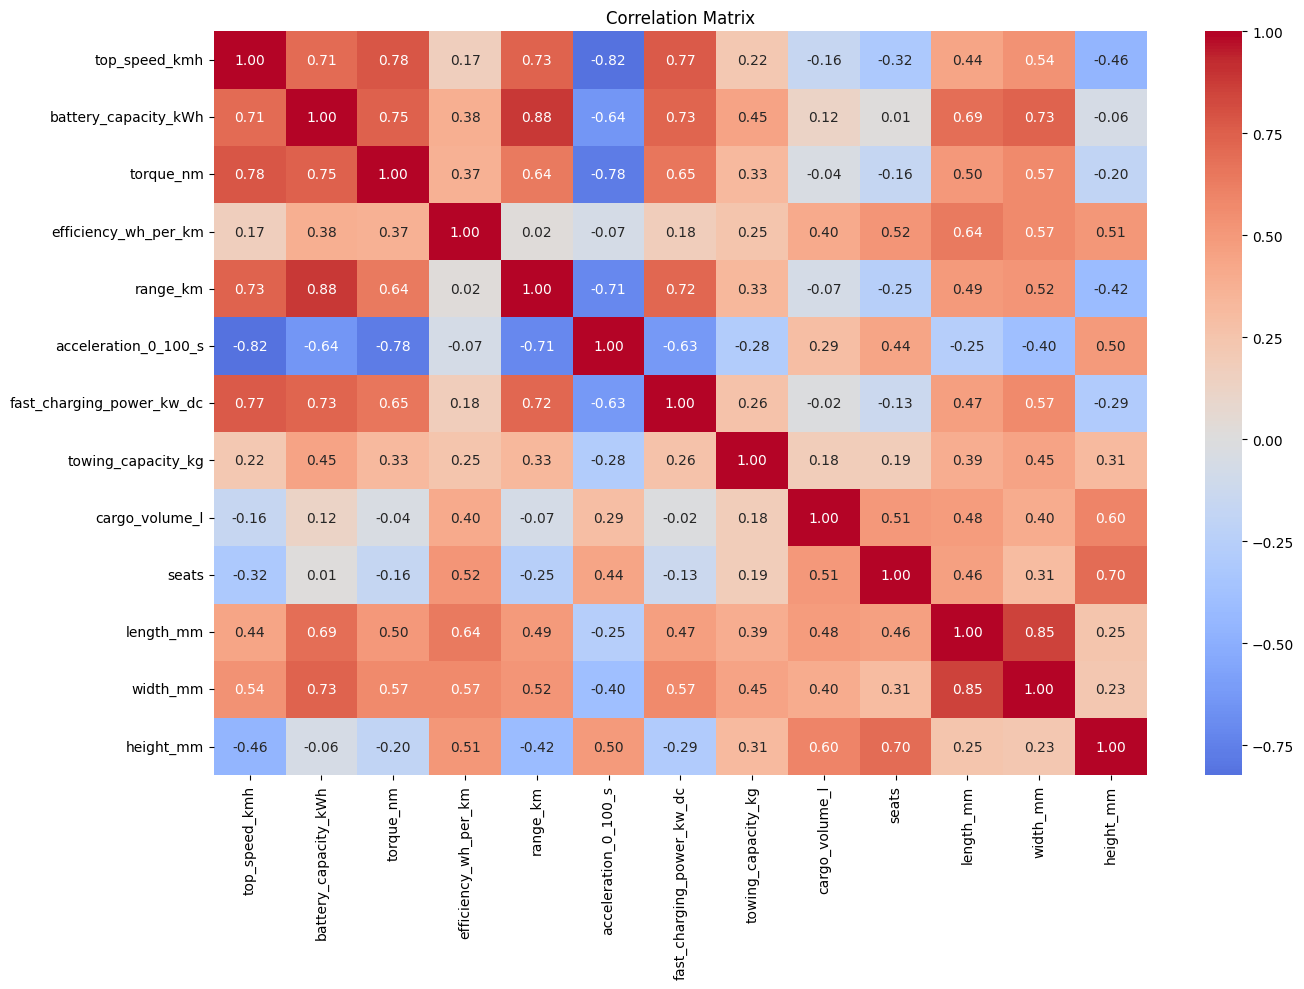

range_km ile korelasyonlar (güçlüden zayıfa):
range_km                     1.000000
battery_capacity_kWh         0.879917
top_speed_kmh                0.731414
fast_charging_power_kw_dc    0.718820
torque_nm                    0.640219
width_mm                     0.522354
length_mm                    0.494275
towing_capacity_kg           0.333651
efficiency_wh_per_km         0.019792
cargo_volume_l              -0.066841
seats                       -0.250072
height_mm                   -0.415670
acceleration_0_100_s        -0.712777
Name: range_km, dtype: float64


In [53]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# range_km ile korelasyonları sıralı göster
print("range_km ile korelasyonlar (güçlüden zayıfa):")
print(correlation_matrix['range_km'].sort_values(ascending=False))

In [54]:
categorical_features = ['drivetrain', 'segment', 'car_body_type', 'fast_charge_port']

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Number of columns after encoding:", df_encoded.shape[1])
print(df_encoded.head())

Number of columns after encoding: 39
    brand                model  top_speed_kmh  battery_capacity_kWh  \
0  Abarth     500e Convertible            155                  37.8   
1  Abarth       500e Hatchback            155                  37.8   
2  Abarth  600e Scorpionissima            200                  50.8   
3  Abarth         600e Turismo            200                  50.8   
4  Aiways                   U5            150                  60.0   

   torque_nm  efficiency_wh_per_km  range_km  acceleration_0_100_s  \
0      235.0                   156       225                   7.0   
1      235.0                   149       225                   7.0   
2      345.0                   158       280                   5.9   
3      345.0                   158       280                   6.2   
4      310.0                   156       315                   7.5   

   fast_charging_power_kw_dc  towing_capacity_kg  ...  segment_JF - Luxury  \
0                       67.0         

In [55]:
# Separate the target variable and its attributes
X = df_encoded.drop(columns=['range_km', 'brand', 'model'])
y = df_encoded['range_km']

# %80 train, %20 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

Train set: (381, 36)
Test set: (96, 36)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling finished.")
print("X_train_scaled mean (first 3 column):", X_train_scaled[:, :3].mean(axis=0).round(4))
print("X_train_scaled std (first 3 column):", X_train_scaled[:, :3].std(axis=0).round(4))

Scaling finished.
X_train_scaled mean (first 3 column): [0. 0. 0.]
X_train_scaled std (first 3 column): [1. 1. 1.]


In [57]:
from sklearn.tree import DecisionTreeRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': round(rmse, 2), 'R²': round(r2, 4)}
    print(f"{name}: RMSE={rmse:.2f}, R²={r2:.4f}")

results_df = pd.DataFrame(results).T
print("\nCompare Model Table:")
print(results_df)

Linear Regression: RMSE=19.66, R²=0.9628
Decision Tree: RMSE=18.80, R²=0.9660
Random Forest: RMSE=17.41, R²=0.9708
Gradient Boosting: RMSE=15.21, R²=0.9777

Compare Model Table:
                    RMSE      R²
Linear Regression  19.66  0.9628
Decision Tree      18.80  0.9660
Random Forest      17.41  0.9708
Gradient Boosting  15.21  0.9777


In [58]:
from sklearn.model_selection import GridSearchCV

# Random Forest için parametre grid'i
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_scaled, y_train)

print("Optimal Parameters for Random Forest:", rf_grid.best_params_)
print("Random Forest Best CV R²:", round(rf_grid.best_score_, 4))

# Parameter grid for Gradient Boosting
gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train_scaled, y_train)

print("\nGradient Boosting: Optimal Parameters:", gb_grid.best_params_)
print("Gradient Boosting: Best CV R²:", round(gb_grid.best_score_, 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Optimal Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest Best CV R²: 0.9497
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Gradient Boosting: Optimal Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Gradient Boosting: Best CV R²: 0.9664


In [59]:
# Retrain using the best parameters
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

# Evaluate on the test set
for name, model in [('Random Forest (Tuned)', best_rf), ('Gradient Boosting (Tuned)', best_gb)]:
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: RMSE={rmse:.2f}, R²={r2:.4f}")

Random Forest (Tuned): RMSE=16.96, R²=0.9723
Gradient Boosting (Tuned): RMSE=13.54, R²=0.9824


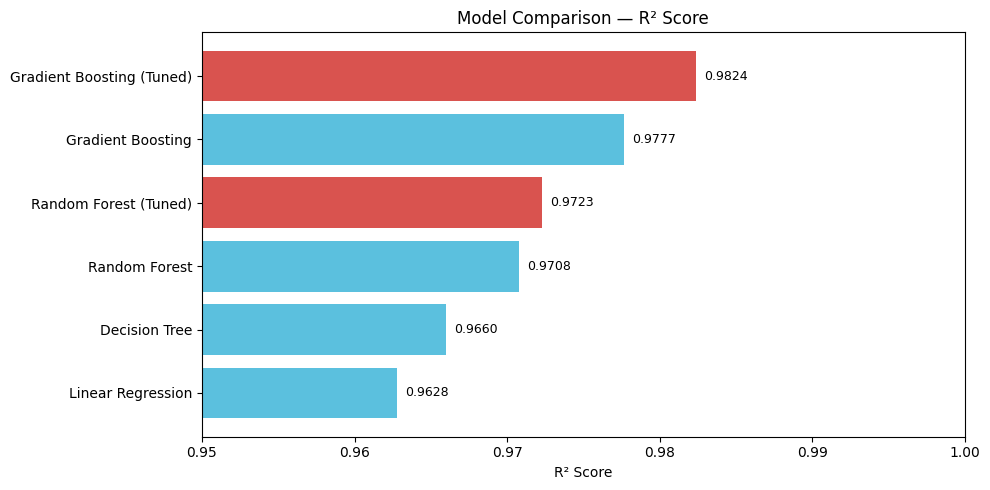

                            RMSE      R²
Linear Regression          19.66  0.9628
Decision Tree              18.80  0.9660
Random Forest              17.41  0.9708
Random Forest (Tuned)      16.96  0.9723
Gradient Boosting          15.21  0.9777
Gradient Boosting (Tuned)  13.54  0.9824


In [60]:
final_results = {
    'Linear Regression':        {'RMSE': 19.66, 'R²': 0.9628},
    'Decision Tree':             {'RMSE': 18.80, 'R²': 0.9660},
    'Random Forest':             {'RMSE': 17.41, 'R²': 0.9708},
    'Random Forest (Tuned)':     {'RMSE': 16.96, 'R²': 0.9723},
    'Gradient Boosting':         {'RMSE': 15.21, 'R²': 0.9777},
    'Gradient Boosting (Tuned)': {'RMSE': 13.54, 'R²': 0.9824},
}

final_df = pd.DataFrame(final_results).T

plt.figure(figsize=(10, 5))
colors = ['#d9534f' if 'Tuned' in i else '#5bc0de' for i in final_df.index]
bars = plt.barh(final_df.index, final_df['R²'], color=colors)
plt.xlabel('R² Score')
plt.title('Model Comparison — R² Score')
plt.xlim(0.95, 1.0)
for bar, val in zip(bars, final_df['R²']):
    plt.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(final_df)

                              Feature  Importance
1                battery_capacity_kWh    0.790180
11                          height_mm    0.078773
5           fast_charging_power_kw_dc    0.036685
3                efficiency_wh_per_km    0.027968
0                       top_speed_kmh    0.020026
27          segment_N - Passenger Van    0.014763
32                car_body_type_Sedan    0.008359
7                      cargo_volume_l    0.004921
33  car_body_type_Small Passenger Van    0.004297
2                           torque_nm    0.003386
4                acceleration_0_100_s    0.002884
10                           width_mm    0.002730
9                           length_mm    0.001956
6                  towing_capacity_kg    0.000907
8                               seats    0.000449


/tmp/ipykernel_471/1186321013.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(15), x='Importance', y='Feature', palette='viridis')


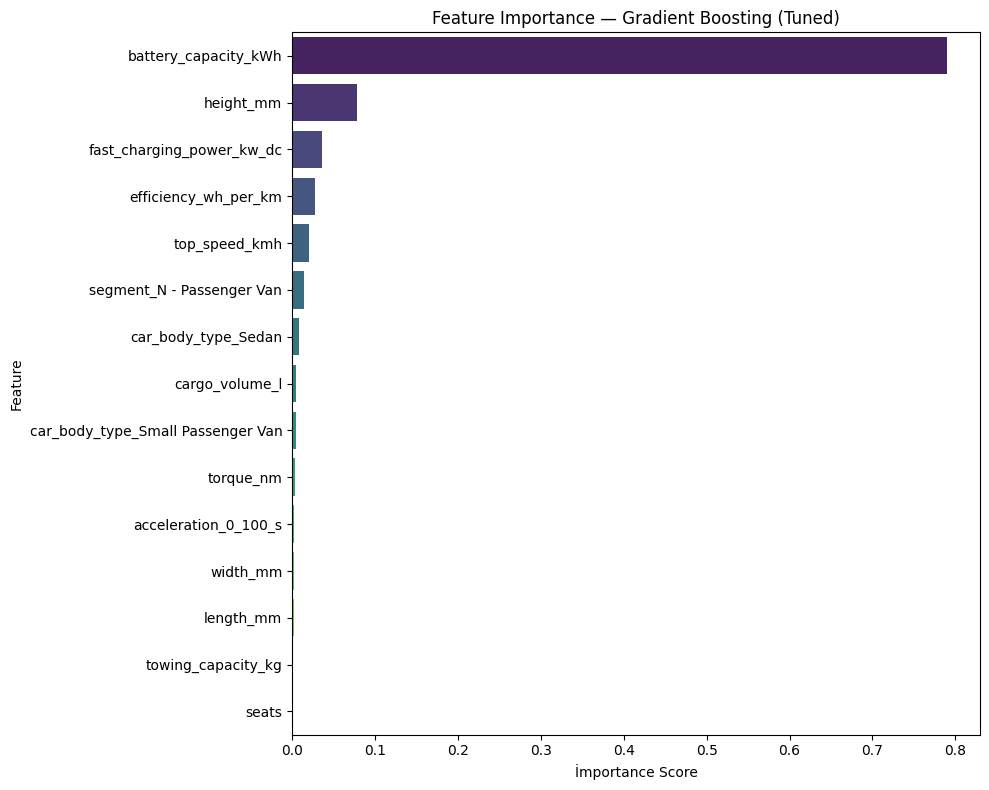

In [61]:
# Feature Importance
feature_names = X_train.columns.tolist()
importances = best_gb.feature_importances_

# Convert to a DataFrame and sort
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(fi_df.head(15))

# Graphic
plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Gradient Boosting (Tuned)')
plt.xlabel('İmportance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

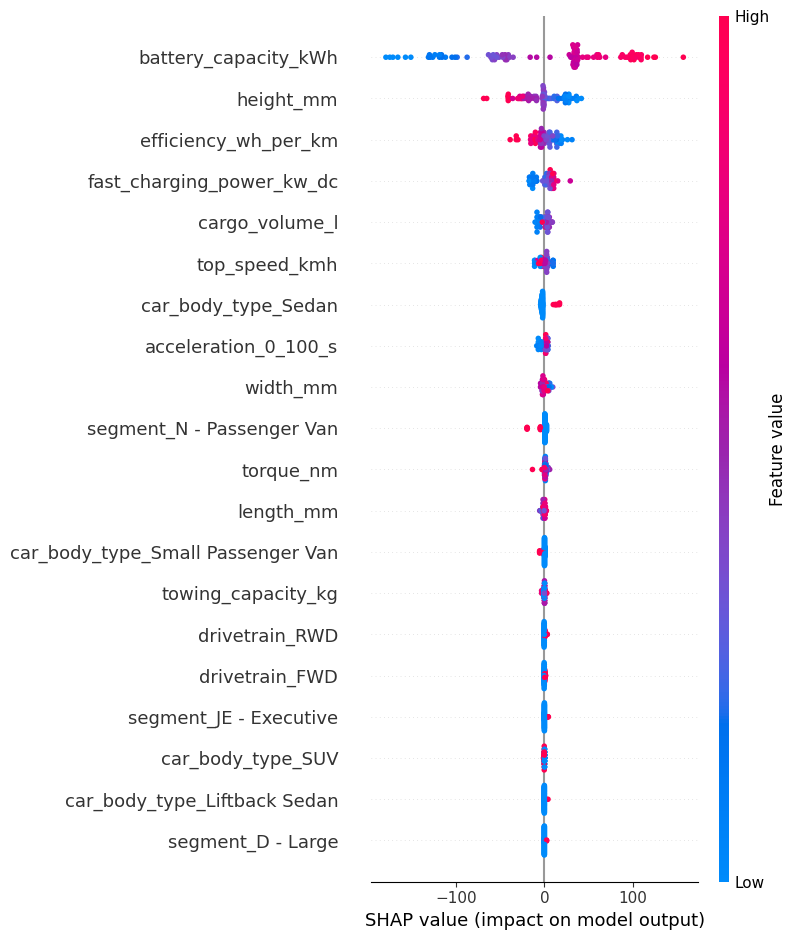

<Figure size 640x480 with 0 Axes>

In [62]:
!pip install shap -q

import shap

explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_test_scaled)

# Detailed SHAP graph
plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names)
plt.tight_layout()
plt.show()

/tmp/ipykernel_471/3489554059.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shap_importance.head(15),


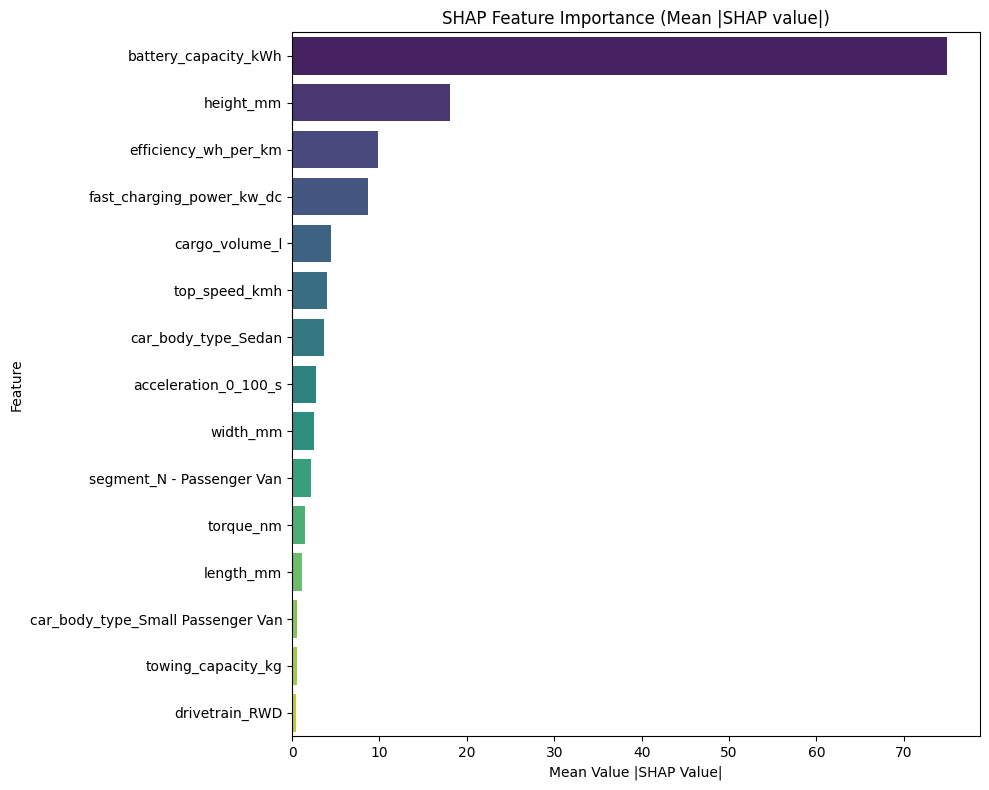

                      Feature  SHAP Importance
1        battery_capacity_kWh        74.968344
11                  height_mm        18.126997
3        efficiency_wh_per_km         9.838834
5   fast_charging_power_kw_dc         8.664802
7              cargo_volume_l         4.507398
0               top_speed_kmh         4.021797
32        car_body_type_Sedan         3.661339
4        acceleration_0_100_s         2.729258
10                   width_mm         2.463404
27  segment_N - Passenger Van         2.154317


In [63]:
# SHAP bar graph
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=shap_importance.head(15),
            x='SHAP Importance',
            y='Feature',
            palette='viridis')
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.xlabel('Mean Value |SHAP Value|')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(shap_importance.head(10))